<center><h1>Etiquetado Morfosintáctico con cadenas de Markov</center>

<b>Maestría</b>: Inteligencia Artificial Aplicada <br>
<b>Asignatura:</b> Procesamiento Acelerado de Lenguaje Natural <br>
<b>Profesor:</b> Edwin J. Rueda

<p>El etiquetado morfosintáctico es el proceso por el cual se asigna una categoria gramatical (sustantivo, verbo, adjetivo, etc) a cada palabra dentro de una oración:</p>
<img src="./images/etiquetas.png" width="400" height="200">

#### ¿Por qué es importante el POS (Part-of-Speech) tagging?

- Este ayuda a entender a los modelos siguientes la estructura gramatical de una oración, permitiendo analizar de forma correcta las oraciones, ya que pueden haber palabras, que dependiendo del contexto, tengan un significado diferente:
    - Voy al **banco** mañana | <b>Banco</b> esa idea  ( sustantivo | verbo )
    - Me voy a tomar unas copas de <b>vino</b> | Él <b>vino</b> a la reunión ( sustantivo | verbo )
    - La <b>llama</b> es nativa de sur américa | Si ella me <b>llama</b>, es mejor contestar ( sustantivo | verbo )
 - Procesamiento previo que se puede usar antes de lematizar palabras y mejorar así la lematización (consiste en reducir una palabra a su forma base/lema).
     - <b>Amazon</b> brinda servicios en la nube -> (Amazon en un nombre propio <b>PROPN</b>)
     - El <b>Amazonas</b> es uno de los 32 departamentos de colombia -> (Sustantivo común)

- Permite mejorar la búsqueda en banco de datos al lograr identificar las palabras clave:
    - Cómo <b>configurar</b> una <b>impresora</b> ? -> Se puede identificar <b>configurar</b> como verbo e <b>impresora</b> como sustantivo y buscar por estar palabras.

### Cadenas de Markov
Las cadenas de Markov son extensiones de los autómatas finitos deterministas, las cuales cumplen las siguientes condiciones:
- Las transiciones representan la probabilidad de ir de un estado $q_{i}$ a $q_{i+1}$.
- Los estados que se visitan dependen únicamente de la cadena de entrada.

Entonces, podemos definir una cadena de Markov como:

$$ Q = q_{1}, q_{2} ... q_{n} \hspace{3mm} \text{Conjunto $Q$ de $n$ estados} $$

$$ A = a_{00} ... a_{nn} \hspace{3mm} \text{Matriz de probabilidades de transición}$$

Donde cada casilla de la matriz $a_{ij}$ representa la probabilidad de ir del estado $i$ al estado $j$. A su vez, contamos con los estado $q_{o}$ y $q_{F}$. Estamos iniciales y finales.

Se asume la propiedad de que la probabilidad de estar en un estado $i$, únicamente depende del estado anterior $i-1$ (<b>propiedad de Markov</b>):

$$ P(q_{i}|q_{o} ... q_{i-1}) =  P(q_{i} | q_{i-1})$$

#### Ejemplo de una cadena de Markov

Supongamos que tenemos la sentencia ***"el hombre corre"***. Dadas las etiquetas POS (ART, SUST, VERB, OTRO). Por lo cual, nuestra cadena de markov tendría 4 estados (uno para cada etiqueta POS):

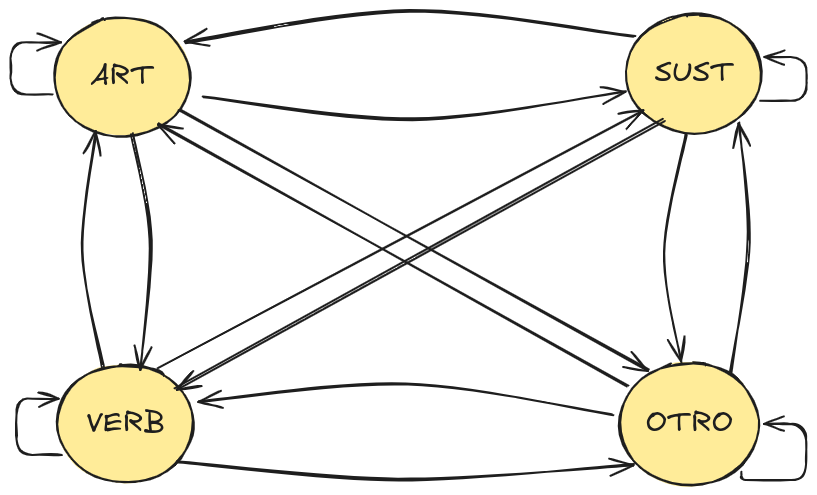

Cómo vemos en la cadena de markov anterior. A partir de un determinado estado, yo puedo ir a cualquiera de los otros estados, o pertenecer en el mismo estado. Esta transición entre estados, está dada por la probabilidad de transición (matriz $ A $):

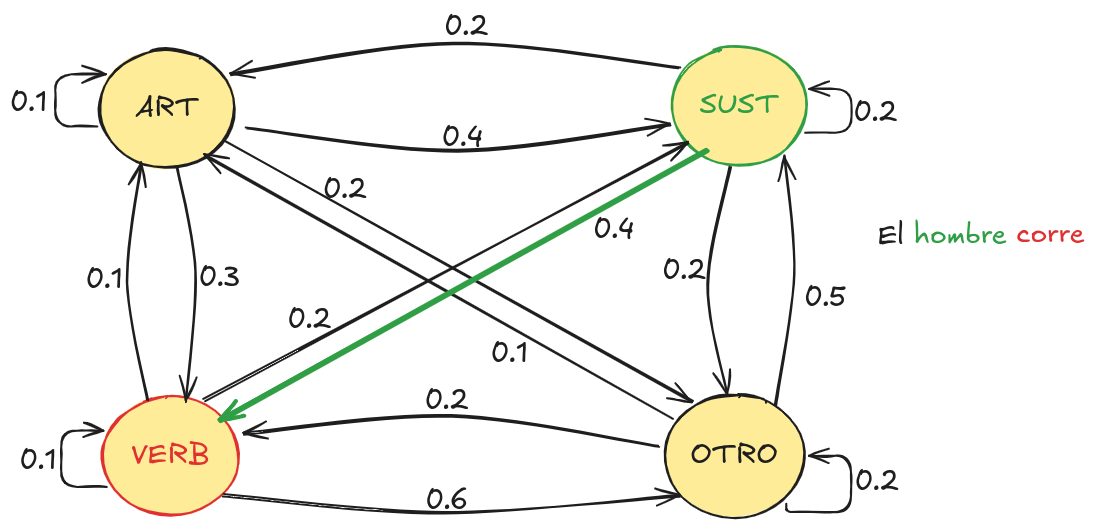 

Al ser las cadenas de Markov un autómata finito y deterministico, debemos contar con un estado inicial de probabilidades $q_{0}$:

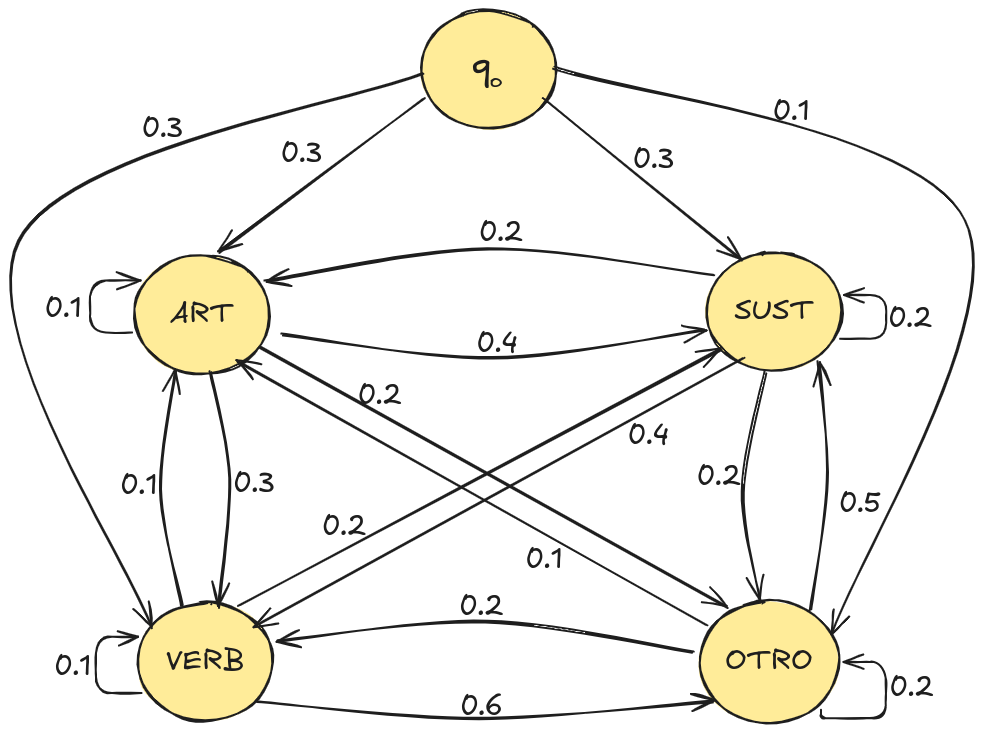

Así, podemos definir que la matriz de transición $A$ sería:

|  | ART | OTRO | SUST | VERB |
| :--- | :---: | :---: | :---: | ---: |
| $q_0$ | $0.3$ | $0.1$ | $0.3$ | $0.3$ |
| ART | $0.1$ | $0.2$ | $0.4$ | $0.3$ |
| OTRO | $0.1$ | $0.2$ | $0.5$ | $0.2$ |
| SUST | $0.2$ | $0.2$ | $0.2$ | $0.4$ |
| VERB | $0.1$ | $0.6$ | $0.2$ | $0.1$ |


$$ A = \begin{bmatrix}
0.3 & 0.1 & 0.3 & 0.3 \\
0.1 & 0.2 & 0.4 & 0.3 \\
0.1 & 0.2 & 0.5 & 0.2 \\
0.2 & 0.2 & 0.2 & 0.4 \\
0.1 & 0.6 & 0.2 & 0.1 
\end{bmatrix}, \sum_{j=1}^{N}a_{ij}=1 $$

Podemos concluir que con la matriz de transición, podemos ir de un estado a otro. Pero esto sucede porque nosotros entendemos la etiqueta de una palabra en el contexto de la oración:

- hombre: SUST
- corre: VERB

pero una máquina no lo comprende. Para ello surgen los ***Hidden Markov Models (HMM)***.

### Hidden Markov Models HMMs
En los modelos ocultos de markov introducimos un nuevo concepto, el de **probabilidad de emisión**, la cual da la probabilidad de ir desde una etiqueta POS, hasta una palabra en específico. Los estados en amarillo, son conocidos como los estados ocultos, y los estados en gris, son los estados observables.

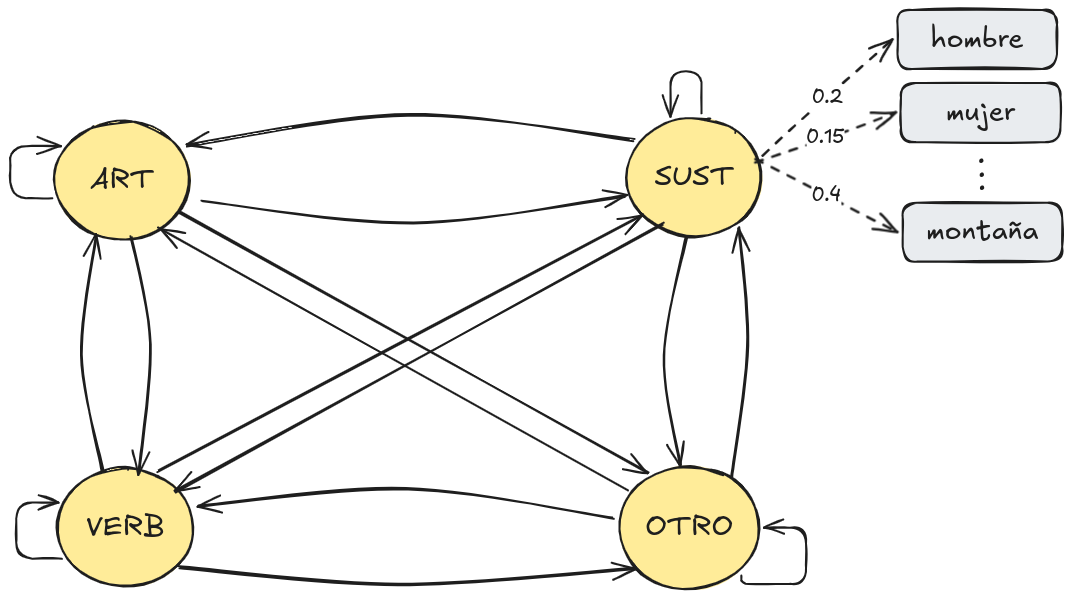

|  | hombre | mujer | montaña | ... |
| :--- | :---: | :---: | :---: | ---: |
| ART | $0.1$ | $0.2$ | $0.1$ | |
| OTRO | $0.1$ | $0.2$ | $0.1$ | |
| SUST | $0.4$ | $0.3$ | $0.2$ | |
| VERB | $0.1$ | $0.1$ | $0.2$ | |

$$\sum_{j=1}^{V}b_{ij}=1 $$

En conclusión, para construir un modelo oculto de markov, necesitamos de $N$ estados, una matriz de transición $A$, y una matriz de emisión $B$:

$$  Q = {q_0, ... , q_N} $$

$$A = \begin{bmatrix}
a_{1,1} & ... & a_{1,N} \\
... & ... &  .... \\
a_{N+1} & ... & a_{N+1,N} 
\end{bmatrix}$$

$$B = \begin{bmatrix}
b_{1,1} & ... & a_{1,V} \\
... & ... &  .... \\
b_{N,1} & ... & a_{N,V} 
\end{bmatrix} , V=\text{vocabulario}$$

Note que la matriz $A$, sus filas van hasta $N+1$, esto debido al estado inicial $q_{0}$.

#### ¿ Cómo calculamos las probabilidades de transición y emisión ? 
Para calcular las probabilidades de transición y emisión debemos procesar el corpus. Para ello, debemos contar con un corpus con sus respectivas etiquetas POS.

##### Probabilidad de transición
Dado un determinado corpus, con 3 etiquetas POS, lo que hacemos es contar las veces que una etiqueta $t_{i-1}$, es seguida por una etiqueta $t_{i}$. Esto nos dará la cantidad de ocurrencias sucesivas de dicha etiqueta (recordando que en las cadenas de markov, la probabilidad de estar en un estado $q_{N}$, depende únicamente del estado inmediatamente anterior, $q_{N-1}$). Estas ocurrencias son dividas por la sumatoria de ocurrencias de la etiqueta $t_{i-1}$ con las demás etiquetas.

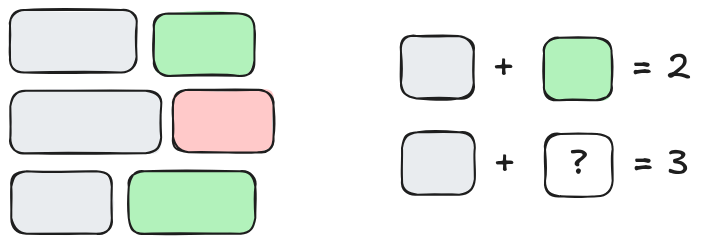

siendo $\frac{2}{3}$ la probabilidad de transición de una etiqueta gris a una etiqueta verde.

En conclusión, para calcular la probabilidad de transición de una etiqueta $t_{i-1}$ a una etiqueta $t_i$. Se tiene que:

- Calcular el número de ocurrencias del par de etiquetas:

$$ C(t_{i-1}, t_i) $$

- Calcular la probabilidad usando la división por el total de pares de etiquetas $t_{i}$, $t_j$:

$$ P(t_i|t_{i-1}) = \frac{C(t_{i-1}, t_i)}{\sum_{j=1}^{N}{C(t_{i-1}, t_j)}} $$

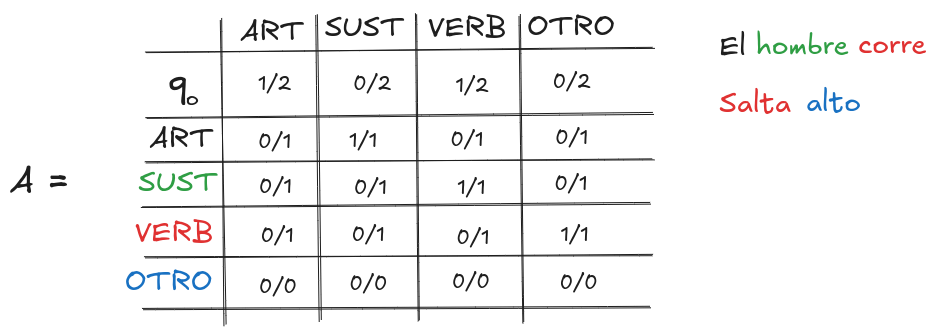

###### Smoothing

Para prevenir divisiones por cero, se aplica un suavizado al calculo de la probabilidad de transición:

$$
P(t_i|t_{i-1}) = \frac{C(t_{i-1}, t_i)+\epsilon}{\sum_{j=1}^{N}{C(t_{i-1}, t_j)}+ N*\epsilon}
$$

##### Probabilidad de emisión
Para poblar la matriz de emisión, debemos contar la cantidad de veces que una etiqueta $t_i$ se asocia a una palabra $w_i$, dividido por la cantidad de veces que aparece la etiqueta $t_i$:

$$
P(w_i|t_{i}) = \frac{C(t_{i}, w_i)+\epsilon}{\sum_{j=1}^{V}{C(t_{i}, w_j)}+ N*\epsilon}
= \frac{C(t_{i}, w_i)+\epsilon}{{C(t_{i})}+ N*\epsilon}
$$

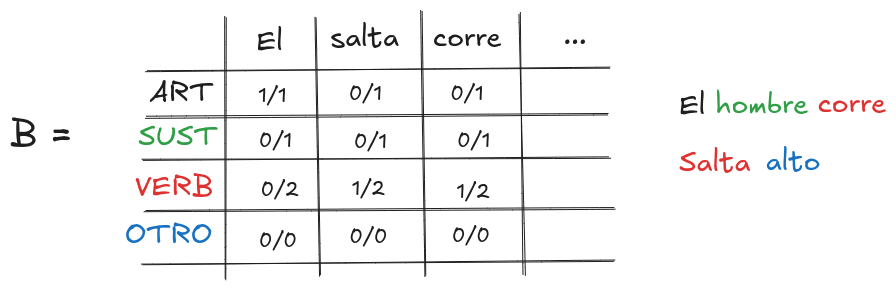

Hasta aquí, hemos consolidado el cómo calcular las matrices de transición $A$, y emisión $B$, dado un corpus de entrenamiento. Pero, dada una nueva sentencia: **¿Cómo podemos asignar las etiquetas POS mas probables?**

### Algortimo de Viterbi

El algoritmo de viterbi nos permite inferir la secuencia de estados ocultos mas probable en un modelo secuencial probabilistico (en este caso, para un HMM), usando programación dinámica y el principio de optimalidad, evitando el bajo rendimiento por explosión combinatoria.
- Si el mejor camino hacia un estado $q_n$ es óptimo, entonces ese prefijo también es parte del camino óptimo completo para llegar a un estado $q_{n+x}$.

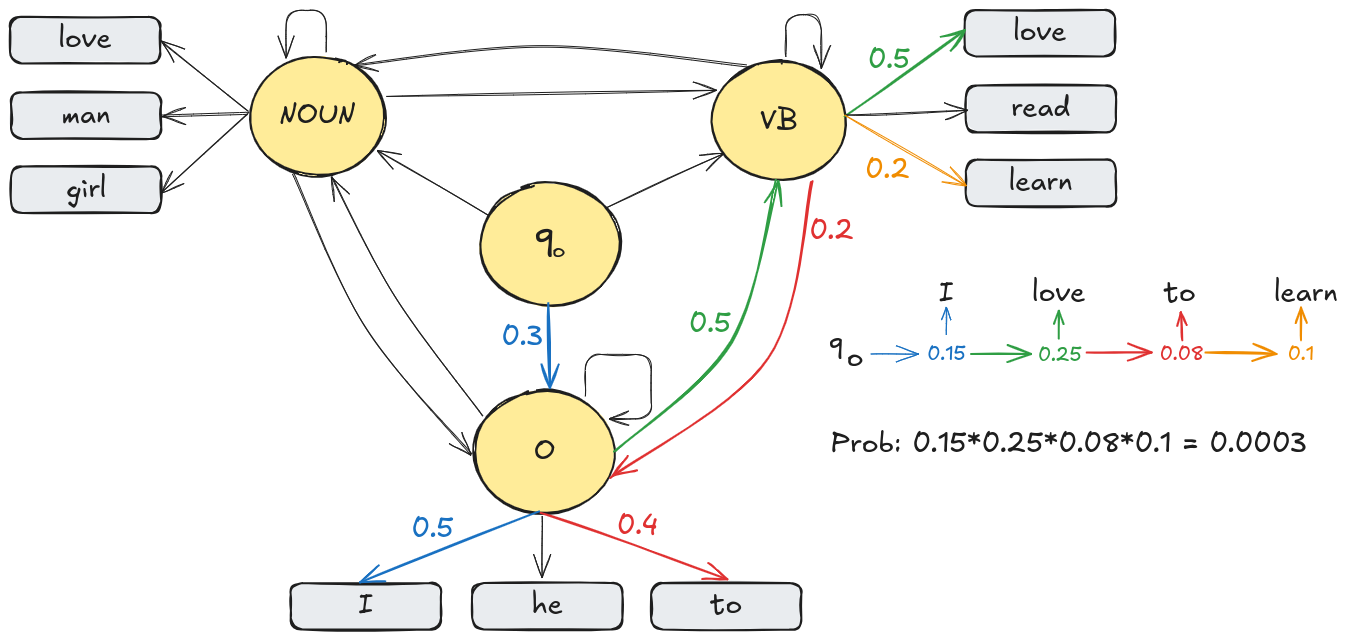

Además de las matrices $A$ y $B$, el algoritmo de viterbi utiliza dos matrices auxiliares:
- $C_{t,k}$: Para almacenar las probabilidades óptimas de llegar a un estado
- $D_{t,k}$: Para almacenar los índices de los estados visitados

donde $t$ es el número de etiquetas POS o el número de estados ocultos, y $k$ es el tamaño del vocabulario.

El algoritmo lo podemos reducir a 3 pasos principales:
- Initialization
- Forward 
- Backward

### Initialization
En este paso, poblamos la primera columna de las matrices $C$ y $D$.

**Poblamos de la matriz $C$, la columna $C_{i,1}$:**

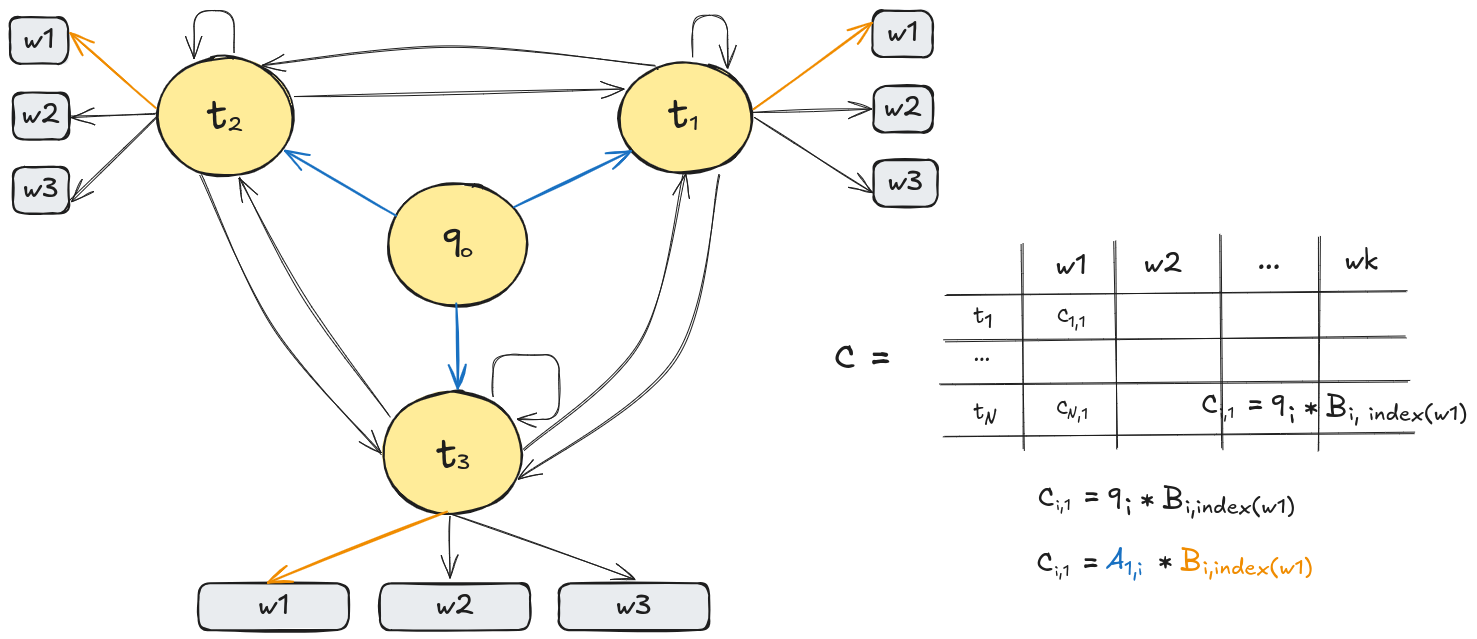

donde $index(w_1)$ es el índice de la palabra $w_1$ en la matriz de emisión.

**Poblamos de la matriz $D$, la columna $D_{t,1}$:**

Recuerda que en la matríz $D$ vamos guardando los estados recorridos. Pero para la primera columna de la matriz $D_{t,1}$ todos los valores serán iguales a cero. Debido a que no nos antecede una etiqueta POS.

$$ D_{t,1} = 0 $$

### Forward Pass
En este paso poblamos las columnas restantes de las matrices $C$ y $D$

**Poblamos la matriz $C$:**

Para poblar el resto de la matriz, tenemos que obtener el máximo de los posibles caminos para llegar a dicho estado $C_{t,k}$:

$$ C_{i,j} = max_{k} C_{k,j-1}*A_{k,i}*B_{i,index(w_{j})} $$

$$ log(C_{i,j}) = max_{k} log(C_{k,j-1})+log(A_{k,i})+log(B_{i,index(w_{j})}) $$

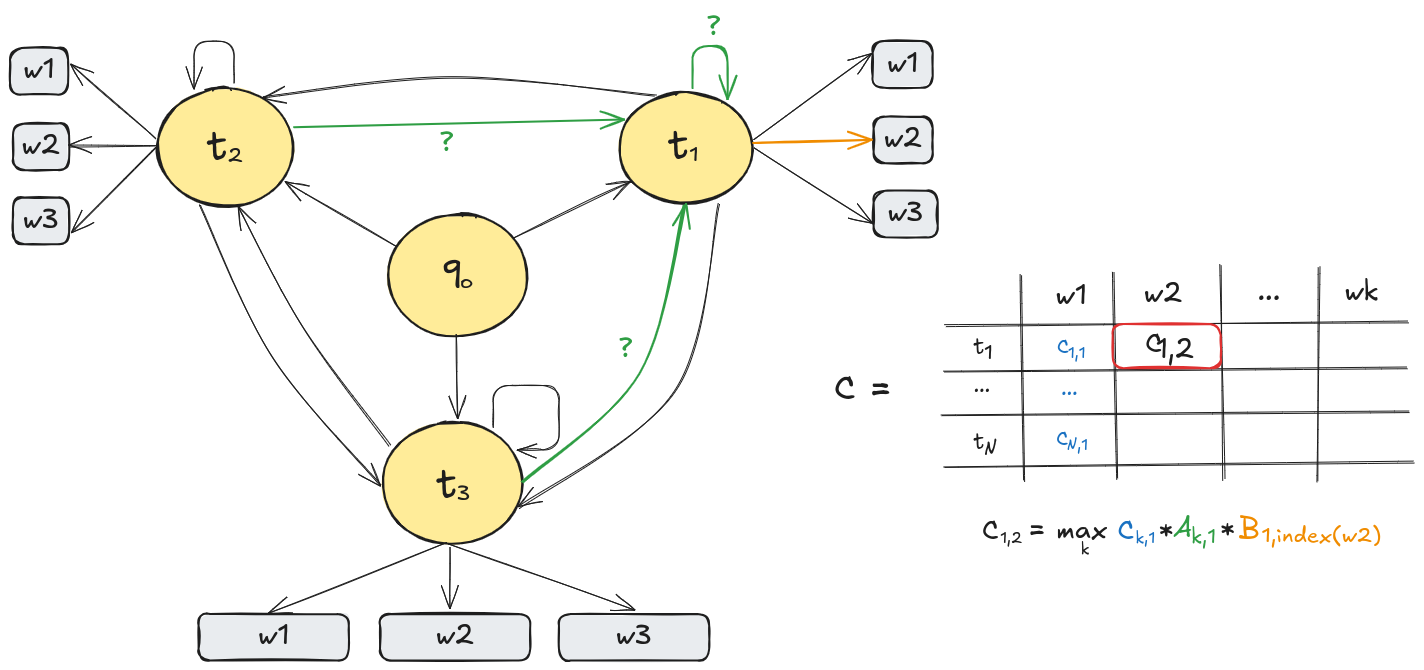

$$ C_{1,2} = max_{k}[ 0.3, 0.001, 0.04] $$
$$ C_{1,2} = 0.3 $$

$$ argmax [0.3, 0.001, 0.04] = 0 $$

**Poblamos la matriz $D$:**

Para poblar la matriz, solo necesitamos ir almacenando el índice/posición del argumento máximo encontrado en la matriz $C$:

$$ d_{i,j} = argmax_{k} C_{k,j-1}*A_{k,i}*B_{i,index(w_{j})} $$

Recuerde que la función $argmax$ retorna el índice del argumento máximo.

### Backward Pass
Este paso, ya tenemos construidas las matrices $A$, $B$, $C$ y $D$. Ahora, construimos las etiquetas POS mas probables para nuestra sentencia.

Nota: Note que las matrices $C$ y $D$ se deben calcular para cada nueva sentencia, ya que dependen del tamaño de la oración y del orden de las palabras.

Como primer paso, debemos calcular el argumento máximo de la última columna de nuestra matriz $C$:

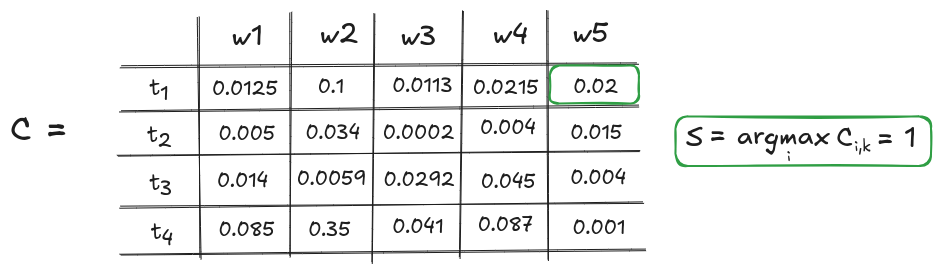

En $S$ obtenemos el índice de la etiqueta con la mayor probabilidad. Ahora, con ayuda de la matriz $D$, reconstruimos las etiquetas:

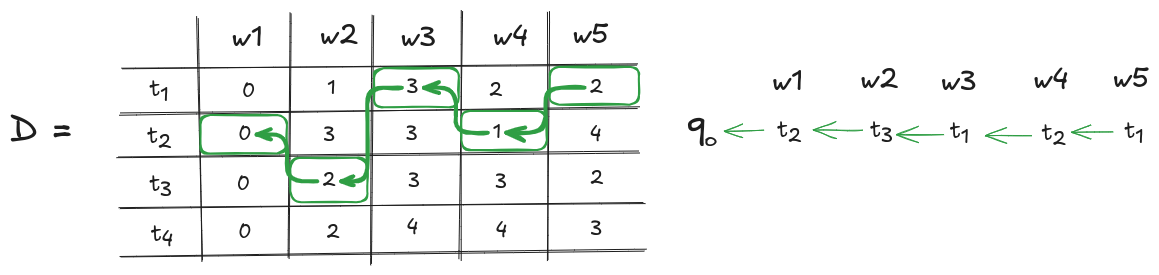

Hasta aquí abarcamos la teoría de cómo construir un etiquetador formosintáctico basado en modelos ocultos de markov!

### Construyamos un etiquetador formosintáctico

In [2]:
from data.utils_pos import get_word_tag, preprocess

Para este ejemplo, usaremos un conjunto de datos en inglés ([Wall Street Journal](http://relearn.be/2015/training-common-sense/sources/software/pattern-2.6-critical-fork/docs/html/mbsp-tags.html)), en el cual contamos con 3 archivos:
- train_corpus.pos usado para el conjunto de entrenamiento
- test_corpus.pos usado para pruebas
- hmm_vocab.txt generado a partir del conjunto de entrenamiento para obtener el vocabulario

#### Cargamos el conjunto de entrenamiento:

In [3]:
with open("./data/train_corpus.pos", 'r') as f:
    training_corpus = f.readlines()

print("6 primeras palabras")
print(training_corpus[0:6])

6 primeras palabras
['In\tIN\n', 'an\tDT\n', 'Oct.\tNNP\n', '19\tCD\n', 'review\tNN\n', 'of\tIN\n']


#### Leemos el vocabulario y lo guardamos en una lista `voc_l`

In [4]:
with open("./data/hmm_vocab.txt", 'r') as f:
    voc_l = f.read().split('\n')

print("Primeras 50 palabras:")
print(voc_l[0:50])
print()
print("50 últimas palabras:")
print(voc_l[-50:])

Primeras 50 palabras:
['!', '#', '$', '%', '&', "'", "''", "'40s", "'60s", "'70s", "'80s", "'86", "'90s", "'N", "'S", "'d", "'em", "'ll", "'m", "'n'", "'re", "'s", "'til", "'ve", '(', ')', ',', '-', '--', '--n--', '--unk--', '--unk_adj--', '--unk_adv--', '--unk_digit--', '--unk_noun--', '--unk_punct--', '--unk_upper--', '--unk_verb--', '.', '...', '0.01', '0.0108', '0.02', '0.03', '0.05', '0.1', '0.10', '0.12', '0.13', '0.15']

50 últimas palabras:
['yards', 'yardstick', 'year', 'year-ago', 'year-before', 'year-earlier', 'year-end', 'year-on-year', 'year-round', 'year-to-date', 'year-to-year', 'yearlong', 'yearly', 'years', 'yeast', 'yelled', 'yelling', 'yellow', 'yen', 'yes', 'yesterday', 'yet', 'yield', 'yielded', 'yielding', 'yields', 'you', 'young', 'younger', 'youngest', 'youngsters', 'your', 'yourself', 'youth', 'youthful', 'yuppie', 'yuppies', 'zero', 'zero-coupon', 'zeroing', 'zeros', 'zinc', 'zip', 'zombie', 'zone', 'zones', 'zoning', '{', '}', '']


#### Ahora necesitamos crear el índice de cada palabra

In [5]:
voc_l[:4]

['!', '#', '$', '%']

In [6]:
vocab = {} 
for n, word in enumerate(sorted(voc_l)): 
    vocab[word] = n       
cnt = 0
for k,v in vocab.items():
    print(f"{k}:{v}")
    cnt += 1
    if cnt > 20:
        break

:0
!:1
#:2
$:3
%:4
&:5
':6
'':7
'40s:8
'60s:9
'70s:10
'80s:11
'86:12
'90s:13
'N:14
'S:15
'd:16
'em:17
'll:18
'm:19
'n':20


In [7]:
# load in the test corpus
with open("./data/test_corpus.pos", 'r') as f:
    y = f.readlines()
    
print("Ejemplo del corpus de prueba:")
print(y[0:10])

Ejemplo del corpus de prueba:
['The\tDT\n', 'economy\tNN\n', "'s\tPOS\n", 'temperature\tNN\n', 'will\tMD\n', 'be\tVB\n', 'taken\tVBN\n', 'from\tIN\n', 'several\tJJ\n', 'vantage\tNN\n']


#### Preprocesamos el corpus con la función auxiliar `preprocess`

In [8]:
_, prep = preprocess(vocab, "./data/test.words")     

print('Tamaño del corpus procesado: ', len(prep))
print('test_corpus: ')
print(prep[0:10])

Tamaño del corpus procesado:  34199
test_corpus: 
['The', 'economy', "'s", 'temperature', 'will', 'be', 'taken', 'from', 'several', '--unk--']


#### Computemos las probabilidades a partir del texto

Tomaremos el corpus_de_entrenamiento y devolveremos los tres diccionarios mencionados anteriormente: **transition_counts**, **emission_counts** y **tag_counts**.

- **transition_counts**: asigna (etiqueta_anterior, etiqueta) al número de veces que ha aparecido.
- **emission_counts**: asigna (etiqueta, palabra) al número de veces que ha aparecido.
- **tag_counts**: asigna (etiqueta) al número de veces que ha ocurrido.

Nota de implementación: esta rutina utiliza defaultdict, que es una subclase de dict.

Un diccionario estándar de Python lanza un KeyError si se intenta acceder a un elemento con una clave que no se encuentra actualmente en el diccionario. Por el contrario, defaultdict creará un elemento del tipo del argumento, en este caso un entero con el valor predeterminado de 0.

In [20]:
from collections import defaultdict

def create_dictionaries(training_corpus, vocab):
    """
    Input: 
        training_corpus: a corpus where each line has a word followed by its tag.
        vocab: a dictionary where keys are words in vocabulary and value is an index
    Output: 
        emission_counts: a dictionary where the keys are (tag, word) and the values are the counts
        transition_counts: a dictionary where the keys are (prev_tag, tag) and the values are the counts
        tag_counts: a dictionary where the keys are the tags and the values are the counts
    """
    ### CODE HERE ###
    emission_counts = defaultdict(int)
    transition_counts = defaultdict(int)
    tag_counts = defaultdict(int)
    prev = '--s--'
    i = 0
    for word_tag in training_corpus:
        i += 1
        if i % 100000 == 0:
            print(f"procesado {i}")
        word, tag = get_word_tag(word_tag, vocab)
        emission_counts[(tag, word)] += 1
        transition_counts[(prev, tag)] += 1
        tag_counts[tag] += 1
        prev = tag
    ##################
    return emission_counts, transition_counts, tag_counts

In [21]:
from time import time
tic = time()
emission_counts, transition_counts, tag_counts = create_dictionaries(training_corpus, vocab)
toc = time()
print(f"tiempo de ejecución {toc-tic} [s]")

procesado 100000
procesado 200000
procesado 300000
procesado 400000
procesado 500000
procesado 600000
procesado 700000
procesado 800000
procesado 900000
tiempo de ejecución 3.269982099533081 [s]


In [ ]:
emission_counts

In [ ]:
transition_counts

In [ ]:
tag_counts

In [26]:
# get all the POS states
states = sorted(tag_counts.keys())
print(f"Número de etiquetas POS (estados ocultos): {len(states)}")
print("Estados ocultos:")
print(states)

Número de etiquetas POS (estados ocultos): 46
Estados ocultos:
['#', '$', "''", '(', ')', ',', '--s--', '.', ':', 'CC', 'CD', 'DT', 'EX', 'FW', 'IN', 'JJ', 'JJR', 'JJS', 'LS', 'MD', 'NN', 'NNP', 'NNPS', 'NNS', 'PDT', 'POS', 'PRP', 'PRP$', 'RB', 'RBR', 'RBS', 'RP', 'SYM', 'TO', 'UH', 'VB', 'VBD', 'VBG', 'VBN', 'VBP', 'VBZ', 'WDT', 'WP', 'WP$', 'WRB', '``']


In [27]:
len(tag_counts.keys())

46

In [28]:
print("Ejemplos de transición: ")
for ex in list(transition_counts.items())[:3]:
    print(ex)
print()

print("ejemplos de emisión: ")
for ex in list(emission_counts.items())[200:203]:
    print (ex)
print()

print("palabras ambigüas: ")
for tup,cnt in emission_counts.items():
    if type(tup) is tuple and tup[1] == 'back': print (tup, cnt) 

Ejemplos de transición: 
(('--s--', 'IN'), 5050)
(('IN', 'DT'), 32364)
(('DT', 'NNP'), 9044)

ejemplos de emisión: 
(('DT', 'any'), 721)
(('NN', 'decrease'), 7)
(('NN', 'insider-trading'), 5)

palabras ambigüas: 
('RB', 'back') 304
('VB', 'back') 20
('RP', 'back') 84
('JJ', 'back') 25
('NN', 'back') 29
('VBP', 'back') 4


#### Función para computar el accuracy de nuestro modelo

Este es un ejercicio de calentamiento/inicial. Lo que haremos es asignar una etiqueta POS a una palabra, asignando la categoría gramatical más frecuente para esa palabra en el conjunto de entrenamiento.

In [30]:
y[:10]

['The\tDT\n',
 'economy\tNN\n',
 "'s\tPOS\n",
 'temperature\tNN\n',
 'will\tMD\n',
 'be\tVB\n',
 'taken\tVBN\n',
 'from\tIN\n',
 'several\tJJ\n',
 'vantage\tNN\n']

In [31]:
def predict_pos(prep, y, emission_counts, vocab, states):
    '''
    Input: 
        prep: a preprocessed version of 'y'. A list with the 'word' component of the tuples.
        y: a corpus composed of a list of tuples where each tuple consists of (word, POS)
        emission_counts: a dictionary where the keys are (tag,word) tuples and the value is the count
        vocab: a dictionary where keys are words in vocabulary and value is an index
        states: a sorted list of all possible tags for this assignment
    Output: 
        accuracy: Number of times you classified a word correctly
    '''
    num_correct = 0
    all_pos_words = set(emission_counts.keys())
    total = len(y)
    ### CODE HERE ###
    for word, y_tup in zip(prep, y):
        if not y_tup.split():
            continue
        _, true_label = y_tup.split()
        post_final = ''
        count_pos_word = 0
        if word in vocab:
            # buscamos por (pos, word)
            for pos in states:
                if ((pos, word) in all_pos_words) and (emission_counts[(pos, word)] > count_pos_word):
                    count_pos_word = emission_counts[(pos, word)]
                    pos_final = pos
        if pos_final == true_label:
            num_correct += 1
    #################
    return num_correct/total

In [32]:
accuracy_predict_pos = predict_pos(prep, y, emission_counts, vocab, states)
print(f"Accuracy: {accuracy_predict_pos:.4f}")

Accuracy: 0.8889


Ahora, veamos cómo incrementa el Acurracy mediante el uso de HMM

#### Creación de la matriz de transición

Implementamos la función `create_transition_matrix` que nos genera la matriz `A`:

In [33]:
trans_keys = set(transition_counts.keys())
print(len(trans_keys), trans_keys)

1421 {('.', 'RB'), ('(', 'NNP'), ('NN', 'JJS'), ('NNS', 'RP'), ('DT', 'CC'), ("''", 'VBP'), ('IN', 'MD'), ('POS', 'CC'), ('JJS', 'PRP'), ('VB', "''"), ('WDT', ','), ('RP', ','), ('PRP', ':'), ('WP$', 'JJ'), ('TO', '--s--'), ('``', 'NNS'), ('IN', 'EX'), ('``', 'PRP$'), ('``', 'WP'), ('JJR', 'NNS'), (':', 'IN'), ('JJR', 'PRP$'), ('JJ', 'VBZ'), (')', 'DT'), ('NNP', 'VBP'), ('WRB', 'JJR'), ('RB', 'POS'), ('MD', 'NN'), ('VB', 'PDT'), ('MD', '('), ('CC', '``'), ('PRP', 'MD'), ('VB', '#'), ('VBD', 'WP'), ('CC', '$'), ("''", 'JJ'), ('WDT', 'JJS'), ('RP', 'JJS'), ('CD', 'RB'), ('``', 'NN'), ('RBR', 'VB'), ('PRP', 'EX'), ('DT', 'NNS'), ('DT', 'PRP$'), ('JJR', 'NN'), ('POS', 'NNS'), ('POS', 'PRP$'), ('IN', ')'), ('JJR', 'NNPS'), ('MD', "''"), ('NNS', 'VBG'), ('VBZ', 'RB'), ('VBD', 'NN'), ('VBD', '('), ('EX', 'PRP'), ('NNP', 'JJ'), ('VBD', 'NNPS'), (':', 'PDT'), ('NNPS', '--s--'), ('VBP', '--s--'), ("''", '.'), ('FW', 'VBZ'), ('.', 'JJ'), ('JJR', "''"), ('WP$', 'VBN'), ('DT', 'IN'), ('PRP', '$'), 

In [38]:
import numpy as np

def create_transition_matrix(alpha, tag_counts, transition_counts):
    ''' 
    Input: 
        alpha: number used for smoothing
        tag_counts: a dictionary mapping each tag to its respective count
        transition_counts: 
    Output:
        A: matrix of dimension (num_tags,num_tags)
    '''
    all_tags = sorted(tag_counts.keys())
    num_tags = len(all_tags)
    A = np.zeros((num_tags,num_tags))
    ### CODE HERE ###
    for i in range(num_tags): # range(A.shape[0])
        for j in range(num_tags): # range(A.shape[1])
            A[i, j] = (transition_counts.get((all_tags[i], all_tags[j]), 0) + alpha) / (tag_counts[all_tags[i]] + (num_tags*alpha))
    #################
    return A

In [40]:
import pandas as pd

alpha = 0.001
A = create_transition_matrix(alpha, tag_counts, transition_counts)
# Testing your function
print(f"A[0,0]: {A[0,0]:.9f}")
print(f"A[3,1]: {A[3,1]:.4f}")

print("parte de la matriz A")
A_sub = pd.DataFrame(A[30:35,30:35], index=states[30:35], columns=states[30:35] )
print(A_sub)

A[0,0]: 0.000007040
A[3,1]: 0.1691
parte de la matriz A
              RBS            RP           SYM        TO            UH
RBS  2.217069e-06  2.217069e-06  2.217069e-06  0.008870  2.217069e-06
RP   3.756509e-07  7.516775e-04  3.756509e-07  0.051089  3.756509e-07
SYM  1.722772e-05  1.722772e-05  1.722772e-05  0.000017  1.722772e-05
TO   4.477336e-05  4.472863e-08  4.472863e-08  0.000090  4.477336e-05
UH   1.030439e-05  1.030439e-05  1.030439e-05  0.061837  3.092348e-02


#### Creación de la matriz de emision

In [43]:
def create_emission_matrix(alpha, tag_counts, emission_counts, vocab):
    '''
    Input: 
        alpha: tuning parameter used in smoothing 
        tag_counts: a dictionary mapping each tag to its respective count
        emission_counts: a dictionary where the keys are (tag, word) and the values are the counts
        vocab: a dictionary where keys are words in vocabulary and value is an index
    Output:
        B: a matrix of dimension (num_tags, len(vocab))
    '''
    ### CODE HERE ###
    all_tags = sorted(tag_counts.keys())
    num_tags = len(all_tags)
    num_words = len(vocab)
    B = np.zeros((num_tags, num_words))
    for i in range(num_tags):
        for j in range(num_words):
            B[i,j] = (emission_counts.get((all_tags[i], vocab[j]), 0) + alpha) / (tag_counts[all_tags[i]] + (num_words*alpha)) 
    
    #################
    return B

In [44]:
alpha = 0.001
B = create_emission_matrix(alpha, tag_counts, emission_counts, list(vocab))

print(f"B[0,0]: {B[0,0]:.9f}")
print(f"B[3,1]: {B[3,1]:.9f}")

# Try viewing emissions for a few words in a sample dataframe
cidx  = ['725','adroitly','engineers', 'promoted', 'synergy']
# Get the integer ID for each word
cols = [vocab[a] for a in cidx]
# Choose POS tags to show in a sample dataframe
rvals =['CD','NN','NNS', 'VB','RB','RP']
# For each POS tag, get the row number from the 'states' list
rows = [states.index(a) for a in rvals]
# Get the emissions for the sample of words, and the sample of POS tags
B_sub = pd.DataFrame(B[np.ix_(rows,cols)], index=rvals, columns = cidx )
print(B_sub)

B[0,0]: 0.000006032
B[3,1]: 0.000000720
              725      adroitly     engineers      promoted       synergy
CD   8.201296e-05  2.732854e-08  2.732854e-08  2.732854e-08  2.732854e-08
NN   7.521128e-09  7.521128e-09  7.521128e-09  7.521128e-09  2.257091e-05
NNS  1.670013e-08  1.670013e-08  4.676203e-04  1.670013e-08  1.670013e-08
VB   3.779036e-08  3.779036e-08  3.779036e-08  3.779036e-08  3.779036e-08
RB   3.226454e-08  6.456135e-05  3.226454e-08  3.226454e-08  3.226454e-08
RP   3.723317e-07  3.723317e-07  3.723317e-07  3.723317e-07  3.723317e-07


Hasta este punto contamos con las matrices `A` y `B`. Los siguientes pasos consisten en la ejecución de los 3 pasos del algoritmo de **viterbi:**

### Inicialización 

In [75]:
import math

def initialize(states, tag_counts, A, B, corpus, vocab):
    '''
    Input: 
        states: a list of all possible parts-of-speech
        tag_counts: a dictionary mapping each tag to its respective count
        A: Transition Matrix of dimension (num_tags, num_tags)
        B: Emission   Matrix of dimension (num_tags, len(vocab))
        corpus: a sequence of words whose POS is to be identified in a list 
        vocab: a dictionary where keys are words in vocabulary and value is an index
    Output:
        best_probs: matrix of dimension (num_tags, len(corpus)) of floats - (C)
        best_paths: matrix of dimension (num_tags, len(corpus)) of integers - (D)
    '''
    num_tags = len(tag_counts)
    best_probs = np.zeros((num_tags, len(corpus)))
    best_paths = np.zeros((num_tags, len(corpus)), dtype=int)
    s_idx = states.index("--s--")
    ### CODE HERE ###
    for i in range(num_tags):
        if A[s_idx, i] != 0:
            best_probs[i,0] = math.log(A[s_idx, i]) + math.log(B[i, vocab[corpus[0]]])
        else:
            best_probs[i,0] = float('-inf')
    #################
    return best_probs, best_paths

In [76]:
best_probs, best_paths = initialize(states, tag_counts, A, B, prep, vocab)

In [77]:
# Test the function
print(f"best_probs[0,0]: {best_probs[0,0]:.4f}")
print(f"best_paths[2,3]: {best_paths[2,3]:.4f}")

best_probs[0,0]: -22.6098
best_paths[2,3]: 0.0000


### Forward Step

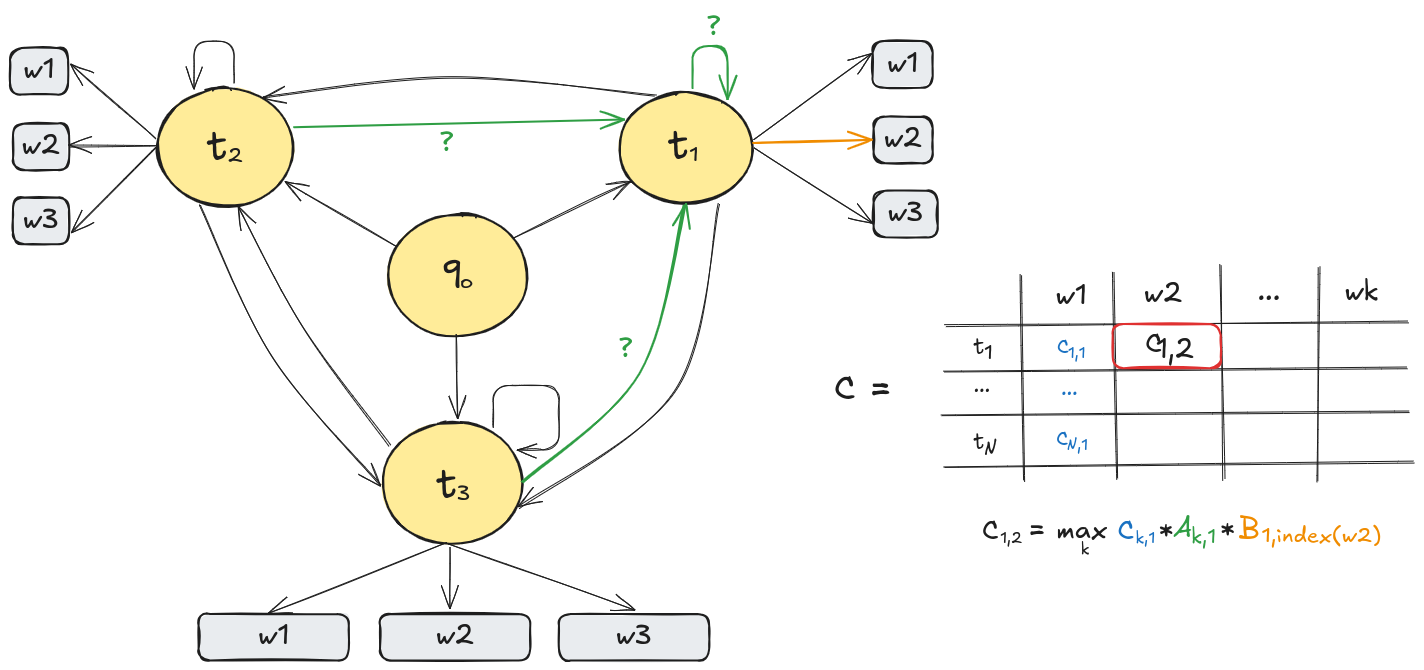

In [91]:
def viterbi_forward(A, B, test_corpus, best_probs, best_paths, vocab):
    '''
    Input: 
        A, B: The transiton and emission matrices respectively
        test_corpus: a list containing a preprocessed corpus
        best_probs: an initilized matrix of dimension (num_tags, len(corpus)) - C
        best_paths: an initilized matrix of dimension (num_tags, len(corpus)) - D
        vocab: a dictionary where keys are words in vocabulary and value is an index 
    Output: 
        best_probs: a completed matrix of dimension (num_tags, len(corpus)) - C
        best_paths: a completed matrix of dimension (num_tags, len(corpus)) - D
    '''
    num_tags = best_probs.shape[0]
    ### CODE HERE ###
    for i in range(1, len(test_corpus)): # iterar por cada palabra
        if i % 5000 == 0:
            print(f"words processed {i}")
        for j in range(num_tags):
            best_prob = float('-inf')
            best_path = -1
            for k in range(num_tags):
                #prob = best_probs[k, i-1] + math.log(A[k, j]) + math.log(B[k, vocab[test_corpus[i]]]) # A(ti, ti+1) , B(ti, wi)
                prob = best_probs[k, i-1] + math.log(A[k, j]) + math.log(B[j, vocab[test_corpus[i]]]) # A(ti, ti+1) , B(ti, wi)
                path = k
                if prob > best_prob:
                    best_prob = prob
                    best_path = path
            best_probs[j, i] = best_prob
            best_paths[j, i] = best_path
    ##################
    return best_probs, best_paths

llenamos las matrices $C$ y $D$

In [92]:
tic = time()
best_probs, best_paths = viterbi_forward(A, B, prep, best_probs, best_paths, vocab)
toc = time()
print(f"forward time: {toc-tic} [s]")

words processed 5000
words processed 10000
words processed 15000
words processed 20000
words processed 25000
words processed 30000
forward time: 104.48307847976685 [s]


### Backward Step

In [93]:
def viterbi_backward(best_probs, best_paths, corpus, states):
    '''
    This function returns the best path.
    
    '''
    ### CODE HERE ###
    m = best_probs.shape[1]
    z = [None] * m
    pred = [None] * m
    num_tags = best_probs.shape[0]
    z[m-1] = np.argmax(best_probs[:, m-1])
    pred[m-1] = states[z[m-1]]

    for j in range(m-2, -1, -1):
        z[j] = best_paths[z[j+1], j+1]
        pred[j] = states[z[j]]
     
    ##################
    return pred

In [94]:
pred = viterbi_backward(best_probs, best_paths, prep, states)
print(f"tamaño de la predicción {len(pred)}")
m=len(pred)
print('predicción[-7:m-1] is: \n', prep[-7:m-1], "\n", pred[-7:m-1], "\n")
print('predicción[0:8] is: \n', pred[0:7], "\n", prep[0:7])

tamaño de la predicción 34199
predicción[-7:m-1] is: 
 ['see', 'them', 'here', 'with', 'us', '.'] 
 ['VB', 'PRP', 'RB', 'IN', 'PRP', '.'] 

predicción[0:8] is: 
 ['DT', 'NN', 'POS', 'NN', 'MD', 'VB', 'VBN'] 
 ['The', 'economy', "'s", 'temperature', 'will', 'be', 'taken']


In [95]:
print('palabra:', prep[6])
print('predicción :', pred[6])
print('target: ', y[6])

palabra: taken
predicción : VBN
target:  taken	VBN



### Computemos el accuracy de Viterbi

In [96]:
" saltar\tVERB ".strip().split("\t")

['saltar', 'VERB']

In [97]:
def compute_accuracy(pred, y):
    '''
    Input: 
        pred: a list of the predicted parts-of-speech 
        y: a list of lines where each word is separated by a '\t' (i.e. word \t tag)
    Output: 
        
    '''
    ### CODE HERE ###
    num_correct = 0
    total = 0
    for prediction, y in zip(pred, y):
        if not y.split():
            continue
        word, tag = y.strip().split('\t')
        if prediction == tag:
            num_correct += 1
        total += 1

    #################
    return num_correct/total

In [98]:
print(f"Accuracy del algoritmo de viterbi: {compute_accuracy(pred, y):.4f}")

Accuracy del algoritmo de viterbi: 0.9531


#### Etiquetar nuevas oraciones

In [100]:
sentence = "he runs every night".split()

mini_C, mini_D = initialize(states, tag_counts, A, B,sentence, vocab)
mini_C, mini_D = viterbi_forward(A, B, sentence, mini_C, mini_D, vocab)
mini_pred = viterbi_backward(mini_C, mini_D, sentence, states)

print(sentence)
print(mini_pred)

['he', 'runs', 'every', 'night']
['PRP', 'VBZ', 'DT', 'NN']


### Corpus en español para entrenar cadenas ocultas de Markov con emisiones gaussianas

Existen grandes cantitades de corpus en diferentes idiomas para entrenar nuestro modelo HMM. Para fines de prática, entrenaremos una cadena oculta de Markov con el corpus CESS-ESP que disponibiliza la librería *nltk*.

In [ ]:
# Importamos la librería
import nltk
from nltk.corpus import cess_esp

##### Entendamos el conjunto de Datos

Este conjunto de datos cuenta con $500.000$ palabras en español. El cual consiste en 610 archivos con oraciones categorizadas. Esta categoría cumple el estándar *EAGLE*, el cual consiste en lo siguiente:
- EL -> da0ms0:
    - d: Determinante
    - a: Artículo
    - 0: N/A
    - m: Género masculino
    - s: Singular
    - 0: N/A
<br><br>
- LA -> da0fs0
    -  d: Determinante
    -  a: Artículo
    -  0: N/A
    -  f: Femenino
    -  s: singular
    -  0: N/A
 
Cómo podemos observar, las categorías (Categoría, género, número, tiempo verbal, etc) podrían usar diferentes estructuras, por ejemplo:
- Adjetivo:
    - Calificativo, ordinal, etc.
- Sustantivo:
    - Común o própio
- Verbo:
    - Principal, Auxiliar

##### Construyamos un traductor del código EAGLE para entender las etiquetas
vamos a utilizar la función ***mapping*** de *nltk* para convertir las etiquetas al estandar universal de morfología

In [ ]:
import numpy as np
from nltk.tag import mapping

In [ ]:
nltk.download('cess_esp')

El mapeo que haremos será sencillo:
- Tomaremos la primera letra del código EAGLE para mapear el tag de la palabra:
$$ map(da0fs0) = D = \text{Determinante/Articulo} $$

**Nota:** Si la letra inicial del código no se encuentra en nuestro diccionario para mapearla, retornaremos *X*.

In [ ]:
def map_eagles_to_universal(tag):
    """
    Convierte etiquetas EAGLES del corpus CESS-ESP a etiquetas universales de Universal POS Tags.
    """
    mapping = {
        "A": "ADJ",  # Adjetivo
        "D": "DET",  # Determinante
        "N": "NOUN",  # Sustantivo
        "V": "VERB",  # Verbo
        "P": "PRON",  # Pronombre
        "R": "ADV",  # Adverbio
        "S": "ADP",  # Preposición
        "C": "CONJ",  # Conjunción
        "I": "INTJ",  # Interjección
        "F": "PUNCT",  # Signo de puntuación
        "Z": "NUM"   # Número
    }
    
    # 📌 Tomar solo la primera letra de la etiqueta EAGLES para el mapeo
    return mapping.get(tag[0], "X")  # "X" si no se reconoce

##### Pre-procesamos el corpus
En este paso haremos lo siguiente:
- Tomaremos solo 300 sentencias etiquetadas (para fines académicos y para disminuir el tiempo de entrenamiento de nuestro HMM).
- Por cada palabra y etiqueta en cada oración:
    - Convertiremos la palabra a minúsculas para evitar que se repitan
    - las eqtiquetas las llevaremos a mayúscula para mapear bien con la función *map_eagles_to_universal*

In [ ]:
processed_corpus = []
sentences = cess_esp.tagged_sents()[:300]
print(f"Corpus sin procesar -> \n {sentences[0]}")
for sentence in sentences:
    pro_sentence = []
    for word, tag in sentence:
        lower_word = word.lower()
        #pro_sentence.append((lower_word, map_eagles_to_universal(tag.upper())))
        pro_sentence.append((lower_word, tag.upper()))
    processed_corpus.append(pro_sentence)
print("-----------------")
print(f"Corpus preprocesado -> \n {processed_corpus[:2]}")

**Extraemos las palabras para mapearlas en números y las etiquetas**

In [ ]:
tags_ = []
sentences_ = []
len_sentences = [] #para pasarle al HMM
words_to_map = set()
words_ = []
for sentence in processed_corpus:
    word_count = 0
    for word, tag in sentence:
        word_count += 1
        words_.append(word)
        words_to_map.add(word)
        tags_.append(tag)
    sentences_.append(words_)
    len_sentences.append(word_count)

unique_tags = np.unique(tags_)
print(f" Cantidad de tags únicos: {len(unique_tags)}")

word_to_index = {word: i for i, word in enumerate(words_to_map)}
index_to_tag = {i: tag for i, tag in enumerate(unique_tags)}

#print(word_to_index)
print("-------------- \n")
print(index_to_tag)

**Construímos el conjunto de entrenamiento**

In [ ]:
X_train = []
for word in words_:
    X_train.append([word_to_index[word]])

print(f"Número de palabras únicas de entrenamiento: {len(words_to_map)}")
print(f"Número de etiquetas: {len(index_to_tag)}")

#### Entrenamos el modelo

In [ ]:
!pip install hmmlearn

In [ ]:
from hmmlearn import hmm
from time import time

tic = time()
len_tags = len(index_to_tag)
modelo_hmm = hmm.GaussianHMM(n_components=len_tags,
                             n_iter=5,
                             random_state=7,
                             verbose=True)

modelo_hmm.fit(X_train, lengths=np.array(len_sentences))
toc = time()
print(f"Tiempo de entrenamiento: {(toc-tic)/60} [min]")

##### Generamos nuevas predicciones

In [ ]:
new_sentence = "el hombre era muy rápido"

idxs = np.array([word_to_index[idx] for idx in new_sentence.split(" ")])
print(f"Oración: {new_sentence} -> index: {idxs}")
predictions = modelo_hmm.predict(idxs.reshape(-1,1))
print(f"Predicción: {predictions}")
prediction_tags = [map_eagles_to_universal(index_to_tag[predict]) for predict in predictions]
print(prediction_tags)

Definimos una función general para generar prediciones

In [ ]:
def get_prediction_tags(sentence):
    words = new_sentence.split(" ")
    idxs = np.array([word_to_index[idx] for idx in words])
    predictions = modelo_hmm.predict(idxs.reshape(-1,1))
    return [(word,  map_eagles_to_universal(index_to_tag[tag])) for word, tag in zip(words, predictions)]
    

In [ ]:
get_prediction_tags(new_sentence)

### Conclusiones

- Los HMM nos permiten estudiar la estructura interna de cada palabra (su morfología).
- Para usar los HMM necesitamos normalizar los datos. Lo cual consiste en transformar el texto bruto en representaciones adecuadas para el HMM.
- Los HMM nos permiten generar etiquetas gramaticales (articulo, verbo, adjetivo, puntuación, etc) a secuencias de palabras/texto.
- Estos modelos asumen que el estado actual dentro de la cadena, depende solo del estado inmediatamente anterior, lo que no permite relaciones mas complejas que las de primer orden.

#### Documentación

- https://www.nltk.org/nltk_data/ corpus en español
- EAGLES stantard https://www.ims.uni-stuttgart.de/en/research/projects/eagles/
- CESS-Cat project (M. Antonia Martí, MarionaTaulé, Lluís Márquez, Manuel Bertran (2007) ?CESS-ECE: A Multilingual and Multilevel Annotated Corpus? in http://www.lsi.upc.edu/~mbertran/cess-ece/publications)
- https://hmmlearn.readthedocs.io/en/latest/
- https://dspace.uib.es/xmlui/bitstream/handle/11201/150347/tfm_2018-19_MADM_act613_2116.pdf?sequence=1&isAllowed=y
- Natural Language Processing with Probabilistic Models https://www.deeplearning.ai/